# Habitat suitability under climate change

Our changing climate is changing where plant species can live,
and conservation and restoration practices will need to take
this into
account.

In this coding challenge, you will create a habitat suitability model
for a terrestrial plant species of your choice that lives in the contiguous United States
(CONUS). We have this limitation because the downscaled climate data we
suggest, the [MACAv2 dataset](https://www.climatologylab.org/maca.html),
is only available in the CONUS – if you find other downscaled climate
data at an appropriate resolution, you are welcome to choose a different
study area. If you don’t have anything in mind, you can take a look at
[*Sorghastrum nutans*](https://www.gbif.org/species/2704414), a grass native to North America. In the past 50
years, its range has moved
northward.

Your suitability assessment will be based on combining multiple data
layers related to soil, topography, and climate, then applying a fuzzy logic model across the different data layers to generate habitat suitability maps. 

You will need to create a **modular, reproducible, workflow** using functions and loops.
To do this effectively, we recommend planning your code out in advance
using a technique such as a pseudocode outline or a flow diagram. We
recommend breaking each of the blocks below out into multiple steps. It
is unnecessary to write a step for every line of code unless you find
that useful. As a rule of thumb, aim for steps that cover the major
structures of your code in 2-5 line chunks.

## STEP 1: Study overview

Before you begin coding, you will need to design your study.

### Step 1a: Select a species
Select the terrestrial plant species you want to study, and research its habitat parameters in scientific studies or other reliable sources. Individual studies may not have the breadth needed for this purpose, so take a look at reviews or overviews of the data. Do **not** just look at an AI-generated summary! In the US, the National Resource Conservation Service can have helpful fact sheets about different species. University Extension programs are also good resources for summaries.</p>
<p>Based on your research, select soil, topographic, and climate variables that you can use to determine if a particular location and time period is a suitable habitat for your species.</p></div></div>

**Reflect and respond**: 
Write a description of your species. What habitat is it found in? What is its geographic range? What, if any, are conservation threats to the species? What data will shed the most light on habitat suitability for this species? 

What core scientific question do you hope to answer about potential future changes in habitat suitability? Don't forget to cite your sources!

Your response here:

Sorghastrum nutans thrives in mostly sunny enviorments and has been found in elevations up to 6,800–9,000 feet, preferring dry to medium-moisture, well-drained soils(USDA), including sandy, loamy, and clay types, just like what most of my yard is made of. It is drought-tolerant and once fully grown and thrives in alkaline, poor, or heavy clay soils. It is found in valleys, stream terraces, and meadows. Much of coloado is suitable for this species of grass. 

11-45 inches of annual precipitation is what it usauly lives on, making it highly drought-tolerant, fire-adapted.

Sorghastrum nutans is found in almost all states east of the Rocky Mountains, including the Midwest, Great Plains, and Southeast, with western, occurrences in UT, AZ, WY, MT, and CO. However there are some outliar regians where the climate allowas this type of grass to grow, amound those outliars are part of south america, sacandinavia, middle east, africa and asia. 

The majority the habitas is in north america which is where I will be doing research for this assignment.

Conservation threats to sorghastrum nutans in Kansas are primarily habitat loss due to agricultural conversion, woody encroachment(Nature Serve), and mismanagement, such as overgrazing or improper haying. Boiling down to lack of regulation and oversite.(Plants)  

My core scientific question: Is the northward range shift of Sorghastrum nutans in the United States correlated with increasing mean annual temperatures in the northern U.S?





https://www.nrcs.usda.gov/plantmaterials/etpmcpg13196.pdf

https://explorer.natureserve.org/Taxon/ELEMENT_GLOBAL.2.722985/Western_Great_Plains_Tallgrass_Prairie#:~:text=Threats%20and%20Other%20Change%20Agents,where%20this%20system%20can%20persist.

https://plants.ces.ncsu.edu/plants/sorghastrum-nutans/#:~:text=The%20plant%20grows%20best%20in,flop%20in%20moist%2C%20rich%20soils.



### Step 1b: Select study sites
Based on your research and/or range maps you find online, select at least 2 sites where your species occurs. These could be national parks, national forests, national grasslands or other protected areas, or some other area you're interested in. You can access protected area polygons from the [US Geological Survey's Protected Area Database](https://www.usgs.gov/programs/gap-analysis-project/science/pad-us-data-overview), [national grassland units](https://data.fs.usda.gov/geodata/edw/edw_resources/shp/S_USA.NationalGrassland.zip), etc.

When selecting your sites, you might want to look for places that are marginally habitable for this species, since those locations will be most likely to show changes due to climate.

Generate a site map for each location.

In [12]:
from pygbif import occurrences
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
import shapely

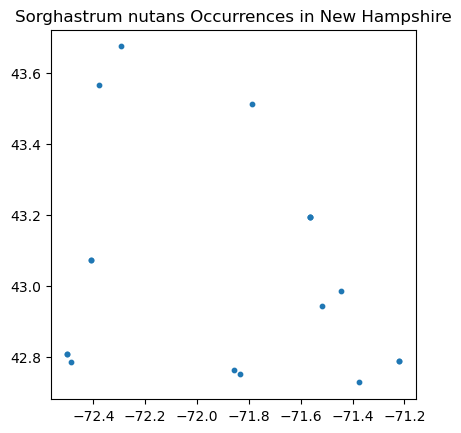

INFO:Created 18 records


In [13]:
# Search for the species key in GBIF
species_name = "Sorghastrum nutans"
species = occurrences.search(scientificName=species_name, limit=1)
taxon_key = species['results'][0]['taxonKey']

# Download occurrences in New Hampshire (stateProvince filter)
records = occurrences.search(
    taxonKey=taxon_key,
    stateProvince="New Hampshire",
    hasCoordinate=True,
    limit=300  # increase if needed (GBIF max per request is 300)
)

# Convert to pandas DataFrame
data = pd.DataFrame(records['results'])

# Keep only relevant columns
data = data[['decimalLatitude', 'decimalLongitude', 'year']].dropna()

#  Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(data['decimalLongitude'], data['decimalLatitude'])]
gdf = gpd.GeoDataFrame(data, geometry=geometry, crs="EPSG:4326")

#  Plot occurrences
gdf.plot(markersize=10)
plt.title("Sorghastrum nutans Occurrences in New Hampshire")
plt.show()

#  Save to file 
gdf.to_file("sorghastrum_nutans_NH.geojson", driver="GeoJSON")

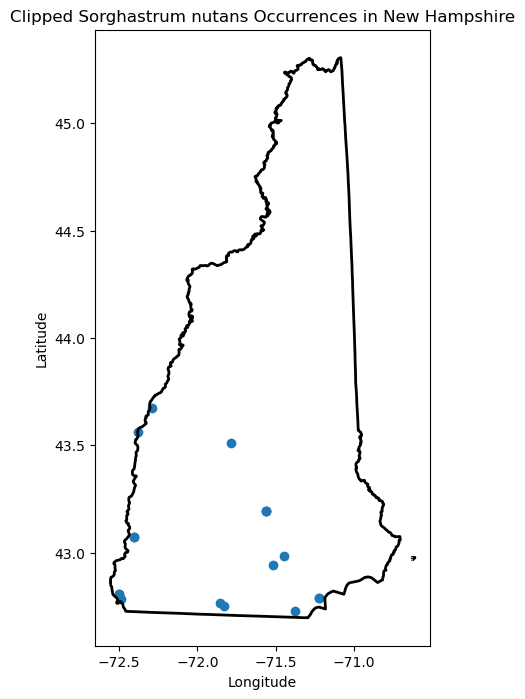

INFO:Created 0 records


In [18]:
# Get GBIF taxon key
species_name = "Sorghastrum nutans"
species = occurrences.search(scientificName=species_name, limit=1)
taxon_key = species['results'][0]['taxonKey']

# Download occurrence data (broader filter)
records = occurrences.search(
    taxonKey=taxon_key,
    hasCoordinate=True,
    country="US",
    limit=300
)

data = pd.DataFrame(records['results'])
data = data[['decimalLatitude', 'decimalLongitude', 'year']].dropna()

geometry = [Point(xy) for xy in zip(data['decimalLongitude'], data['decimalLatitude'])]
occ_gdf = gpd.GeoDataFrame(data, geometry=geometry, crs="EPSG:4326")


# Load New Hampshire boundary
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_500k.zip"
)

nh = states[states["NAME"] == "New Hampshire"]
nh = nh.to_crs("EPSG:4326")

# Spatial clip (strict boundary filter)
clipped_gdf = gpd.clip(occ_gdf, nh)

# Plot results
fig, ax = plt.subplots(figsize=(8, 8))

# State outline
nh.boundary.plot(ax=ax, linewidth=2, color="black")

# plot on the prepared axis
gdf.plot(ax=ax)

ax.set_title("Clipped Sorghastrum nutans Occurrences in New Hampshire")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

# Save output
clipped_gdf.to_file("S_nutans_NH_clipped.geojson", driver="GeoJSON")

In [24]:
import contextily as ctx

In [20]:
# explode in case of multiparts
coords = np.concatenate([
    np.array(geom.coords)
    for geom in gdf.geometry
    if geom.geom_type == "Point"
])

print("Any inf:", np.isinf(coords).any())
print("Any nan:", np.isnan(coords).any())

Any inf: False
Any nan: False


In [21]:
NH_grass = gpd.sjoin(
    gdf,
    nh,
    how="inner",
    predicate="within"
)

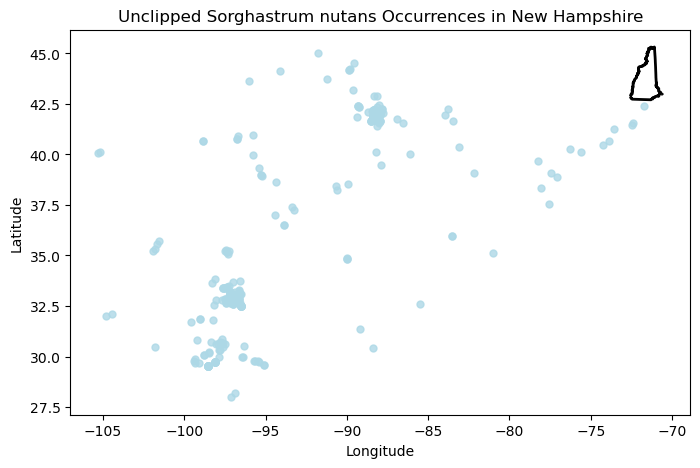

In [23]:
# Alternative: Plot without clipping (broader filter)
fig, ax = plt.subplots(figsize=(8, 8))

# State outline
nh.boundary.plot(ax=ax, linewidth=2, color="black")

# Unclipped occurrence points
occ_gdf.plot(ax=ax, color="lightblue", markersize=25, alpha=0.8)

ax.set_title("Unclipped Sorghastrum nutans Occurrences in New Hampshire")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [ ]:
### Insert your site maps here:

**Reflect and Respond**: 
Write a site description for each of your sites, or for all of your sites as a group if you have chosen a large number of linked sites. What
differences or trends in habitat suitability over time do you expect to see among your sites?

Your response here:

### Step 1c: Select time periods

In general when studying climate, we are interested in **climate
normals**, which are typically calculated from 30 years of data so that
they reflect the climate as a whole and not a single year which may be
anomalous. So if you are interested in the climate around 2050, you will need to access climate data from 2035-2065.

**Reflect and Respond**: Select at least two 30-year time periods to compare, such as historical and 30 years into the future. These time periods should help you to answer your scientific question.

Your response here:

### Step 1d: Select climate models

There is a great deal of uncertainty among the many global climate
models available. One way to work with the variety is by using an
**ensemble** of models to try to capture that uncertainty. This also
gives you an idea of the range of possible values you might expect! To
be most efficient with your time and computing resources, you can use a
subset of all the climate models available to you. However, for each
scenario, you should attempt to include models that are:

-   Warm and wet
-   Warm and dry
-   Cold and wet
-   Cold and dry

for each of your sites.

To figure out which climate models to use, you will need to access
summary data near your sites for each of the climate models. You can do
this using the [Climate Futures Toolbox Future Climate Scatter
tool](https://climatetoolbox.org/tool/Future-Climate-Scatter). There is
no need to write code to select your climate models, since this choice
is something that requires your judgement and only needs to be done
once.

If your question requires it, you can also choose to include multiple
climate variables, such as temperature and precipitation, and/or
multiple emissions scenarios, such as RCP4.5 and RCP8.5.

**Reflect and respond**: Choose at least 4 climate models that cover the range of possible future climate variability at your sites. Which models did you choose, and how did you make that decision?

Your response here (don't forget to cite the Climate Toolbox): 

## STEP 2: Data access

### Step 2a: Soil data

The [POLARIS dataset](http://hydrology.cee.duke.edu/POLARIS/) is a
convenient way to uniformly access a variety of soil parameters such as
pH and percent clay in the US. It is available for a range of depths (in
cm) and split into 1x1 degree tiles.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download POLARIS data for a particular location, soil parameter,
and soil depth. Your function should account for the situation where
your site boundary crosses over multiple tiles, and merge the necessary
data together.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include soil parameters that will help you to
answer your scientific question. We recommend using a soil depth that
best corresponds with the rooting depth of your species.</p></div></div>

In [ ]:
### Download and process soil data

In [ ]:
### Visualize the soil data

### Step 2b: Topographic data

Depending on your species habitat needs/environmental parameters, you might be interested in elevation, slope, and/or aspect. You can access reliable elevation data from the [SRTM
dataset](https://www.earthdata.nasa.gov/data/instruments/srtm),
available through the [earthaccess
API](https://earthaccess.readthedocs.io/en/latest/quick-start/). Once you have elevation data, you can calculate slope and aspect.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download SRTM elevation data for a particular location and
calculate any additional topographic variables you need such as slope or
aspect.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include topographic parameters that will help you
to answer your scientific question.</p></div></div>

> **Warning**
>
> Be careful when computing the slope from elevation that the units of
> elevation match the projection units (e.g. meters and meters, not
> meters and degrees). You will need to project the SRTM data to
> complete this calculation correctly.

In [ ]:
### Download and process topographic data

In [ ]:
### Visualize the topographic data

### Step 2c: Climate model data

You can use MACAv2 data for historical and future climate data. Be sure
to compare at least two 30-year time periods (e.g. historical vs. 10
years in the future) for at least four of the CMIP models. Overall, you
should be downloading at least 8 climate rasters for each of your sites,
for a total of 16. **You will *need* to use loops and/or functions to do
this cleanly!**.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download MACAv2 data for a particular climate model, emissions
scenario, spatial domain, and time frame. Then, use loops to download
and organize the 16+ rasters you will need to complete this section. The
<a
href="http://thredds.northwestknowledge.net:8080/thredds/reacch_climate_CMIP5_macav2_catalog2.html">MACAv2
dataset is accessible from their Thredds server</a>. Include an
arrangement of sites, models, emissions scenarios, and time periods that
will help you to answer your scientific question.</p></div></div>

In [ ]:
### Download climate data

**Reflect and respond**: Make sure to include a description of the climate data and how you selected your models. Include a citation of the MACAv2 data.

Your response here:

## STEP 3: Harmonize data
To use all your environmental and climate data layers together, you need to harmonize the different rasters you've downloaded and processed. 

As a first step, make sure that the grids for all the rasters match each other. Check out the <a href="https://corteva.github.io/rioxarray/stable/examples/reproject_match.html#Reproject-Match"><code>ds.rio.reproject_match()</code> method</a> from <code>rioxarray</code>. Make sure to use the data source that has the highest resolution as a template!</p></div></div>

> **Warning**
>
> If you are reprojecting data (as you need to here), the order of
> operations is important! Recall that reprojecting will typically tilt
> your data, leaving narrow sections of the data at the edge blank.
> However, to reproject efficiently it is best for the raster to be as
> small as possible before performing the operation. We recommend the
> following process:
>
>     1. Crop the data, leaving a buffer around the final boundary
>     2. Reproject to match the template grid (this will also crop any leftovers off the image)

In [ ]:
### Align the grids of the different data layers

## STEP 4: Develop a fuzzy logic model

A fuzzy logic model is one that is built on expert knowledge rather than
training data. You may wish to use the
[`scikit-fuzzy`](https://pythonhosted.org/scikit-fuzzy/) library, which
includes many utilities for building this sort of model. In particular,
it contains a number of **membership functions** which can convert your
data into values from 0 to 1 using information such as, for example, the
maximum, minimum, and optimal values for soil pH.

To train a fuzzy logic habitat suitability model:</p>
<pre><code>1. Find the optimal values for your species for each variable you are using (e.g. soil pH, slope, and current annual precipitation). 
2. For each **digital number** in each raster, assign a **continuous** value from 0 to 1 for how close that grid square/pixel is to the optimum range (1 = optimal, 0 = incompatible). 
3. Combine your layers by multiplying them together. This will give you a single suitability number for each grid square.
4. Optionally, you may apply a suitability threshold to make the most suitable areas pop on your map.</code></pre></div></div>

> **Tip**
>
> If you use mathematical operators on a raster in Python, it will
> automatically perform the operation for every number in the raster.
> This type of operation is known as a **vectorized** function. **DO NOT
> DO THIS WITH A LOOP!**. A vectorized function that operates on the
> whole array at once will be much easier and faster.

In [ ]:
### Create fuzzy logic model for habitat suitability

## STEP 5: Present your results
Generate some plots that show your key findings of habitat suitability in your study sites across the different time periods and climate models. Don’t forget to interpret your plots!

In [ ]:
### Create plots

Interpret your plots here: